In [14]:
# CELL 1: Configuration (UPDATED)
from pathlib import Path

# Dataset paths (AFTER extracting ZIP)
CARIES_PATH = r'C:\Users\bacus\Downloads\Dental OPG XRAY Dataset\Dental OPG XRAY Dataset\Dental OPG (Classification)\Caries'
HEALTHY_PATH = r'C:\Users\bacus\Downloads\Dental OPG XRAY Dataset\Dental OPG XRAY Dataset\Dental OPG (Classification)\Healthy Teeth'

# Training Configuration
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
MODEL_NAME = 'dental_caries_classifier'
VALIDATION_SPLIT = 0.2

In [15]:
!pip install tensorflow opencv-python pillow matplotlib scikit-learn albumentations seaborn


In [16]:
import tensorflow as tf
import numpy as np
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import albumentations as A

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU available: {len(gpus)} device(s)")
else:
    print("No GPU found, using CPU")

No GPU found, using CPU


In [17]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

val_transform = None  # No augmentation for validation

In [18]:
def load_dataset(caries_dir, healthy_dir, img_size):
    """Load images from both directories and create labels"""
    images = []
    labels = []
    
    # Load Caries images (label = 1)
    caries_path = Path(caries_dir)
    if not caries_path.exists():
        raise ValueError(f"Caries directory not found: {caries_dir}")
    
    caries_files = [f for f in caries_path.glob('*.*') 
                    if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
    
    print(f"Loading {len(caries_files)} caries images...")
    for img_path in caries_files:
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(1)  # Caries = 1
        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
    
    # Load Healthy images (label = 0)
    healthy_path = Path(healthy_dir)
    if not healthy_path.exists():
        raise ValueError(f"Healthy directory not found: {healthy_dir}")
    
    healthy_files = [f for f in healthy_path.glob('*.*') 
                     if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
    
    print(f"Loading {len(healthy_files)} healthy images...")
    for img_path in healthy_files:
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(0)  # Healthy = 0
        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
    
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    
    print(f"\nTotal images loaded: {len(images)}")
    print(f"Caries: {np.sum(labels == 1)}, Healthy: {np.sum(labels == 0)}")
    print(f"Images shape: {images.shape}")
    
    return images, labels

In [19]:
# CELL 6: Create TensorFlow Datasets (SIMPLER - NO AUGMENTATION IN PIPELINE)
def create_tf_dataset(images, labels, batch_size, is_training=True):
    """Create TensorFlow dataset - augmentation applied before this"""
    
    # Normalize
    images = images.astype(np.float32) / 255.0
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

In [20]:
# CELL 7: Load and Split Data (UPDATED)
print("Loading dataset...")
X, y = load_dataset(CARIES_PATH, HEALTHY_PATH, IMG_SIZE)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VALIDATION_SPLIT, random_state=42, stratify=y
)

# Apply augmentation to training data
if train_transform is not None:
    print("Applying augmentation to training data...")
    X_train_augmented = []
    for img in X_train:
        augmented = train_transform(image=img)
        X_train_augmented.append(augmented['image'])
    X_train = np.array(X_train_augmented, dtype=np.uint8)

print(f"\nTrain set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Train - Caries: {np.sum(y_train == 1)}, Healthy: {np.sum(y_train == 0)}")
print(f"Val - Caries: {np.sum(y_val == 1)}, Healthy: {np.sum(y_val == 0)}")

# Create TensorFlow datasets (no augmentation in pipeline)
train_dataset = create_tf_dataset(X_train, y_train, BATCH_SIZE, is_training=True)
val_dataset = create_tf_dataset(X_val, y_val, BATCH_SIZE, is_training=False)

Loading dataset...
Loading 119 caries images...
Loading 223 healthy images...

Total images loaded: 342
Caries: 119, Healthy: 223
Images shape: (342, 224, 224, 3)
Applying augmentation to training data...

Train set: 273 images
Validation set: 69 images
Train - Caries: 95, Healthy: 178
Val - Caries: 24, Healthy: 45


In [21]:
# Replace CELL 8 with this:
def build_transfer_learning_model(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze base
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_transfer_learning_model()

In [22]:
# CELL 9: Compile Model with Class Weights
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: Healthy={class_weight_dict[0]:.2f}, Caries={class_weight_dict[1]:.2f}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

Class weights: Healthy=0.77, Caries=1.44


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

output_dir = Path(f'trained_models/{MODEL_NAME}')
output_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        str(output_dir / 'best_model.h5'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(str(output_dir / 'training_log.csv'))
]


In [24]:
print("\nStarting training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # ADD THIS LINE
    verbose=1
)


Starting training...
Epoch 1/30


17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4125 - auc: 0.4538 - loss: 0.8414 - precision: 0.3505 - recall: 0.6307
Epoch 1: val_accuracy improved from None to 0.46377, saving model to trained_models\dental_caries_classifier\best_model.h5


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 333ms/step - accuracy: 0.4359 - auc: 0.4841 - loss: 0.8228 - precision: 0.3254 - recall: 0.5789 - val_accuracy: 0.4638 - val_auc: 0.4528 - val_loss: 0.7253 - val_precision: 0.2903 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 2/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4690 - auc: 0.4352 - loss: 0.8217 - precision: 0.2874 - recall: 0.3255
Epoch 2: val_accuracy did not improve from 0.46377
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.4652 - auc: 0.4516 - loss: 0.8085 - precision: 0.2893 - recall: 0.3684 - val_accuracy: 0.4493 - val_auc: 0.4718 - val_loss: 0.7391 - val_precision: 0.3158 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 3/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4688 - auc: 0.5024 - loss: 0.7888 - precision: 0.3564 - recall: 0.5077
Epoch 3: val_accuracy improved from 0.46377 to 0.49275, saving model to trained_models\dental_caries_classifier\best_model.h5


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.5165 - auc: 0.5150 - loss: 0.7675 - precision: 0.3609 - recall: 0.5053 - val_accuracy: 0.4928 - val_auc: 0.4741 - val_loss: 0.7286 - val_precision: 0.3429 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 4/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5107 - auc: 0.4943 - loss: 0.7522 - precision: 0.3301 - recall: 0.5412
Epoch 4: val_accuracy did not improve from 0.49275
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.4799 - auc: 0.4922 - loss: 0.7775 - precision: 0.3484 - recall: 0.5684 - val_accuracy: 0.4783 - val_auc: 0.4815 - val_loss: 0.7488 - val_precision: 0.3500 - val_recall: 0.5833 - learning_rate: 1.0000e-04
Epoch 5/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5127 - auc: 0.5695 - loss: 0.7176 - precision: 0.4051 - recall: 0.6053
Epoch 5: val_accuracy did not improve from 0.49275
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.4945 - auc: 0.5592 - loss: 0.7086 - precision: 0.35

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.5421 - auc: 0.5314 - loss: 0.7476 - precision: 0.3438 - recall: 0.3474 - val_accuracy: 0.5072 - val_auc: 0.4713 - val_loss: 0.7178 - val_precision: 0.3214 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 7/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6512 - auc: 0.7023 - loss: 0.6207 - precision: 0.5021 - recall: 0.6494
Epoch 7: val_accuracy did not improve from 0.50725
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.6154 - auc: 0.6671 - loss: 0.6552 - precision: 0.4627 - recall: 0.6526 - val_accuracy: 0.4493 - val_auc: 0.4685 - val_loss: 0.7506 - val_precision: 0.3158 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 8/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5538 - auc: 0.5614 - loss: 0.7283 - precision: 0.4197 - recall: 0.5802
Epoch 8: val_accuracy did not improve from 0.50725
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.5348 - auc: 0.5655 - loss: 0.7105 - precision: 0.38

In [25]:
best_model = tf.keras.models.load_model(str(output_dir / 'best_model.h5'))

print("\nEvaluating best model on validation set...")
results = best_model.evaluate(val_dataset, verbose=1)
print(f"\nValidation Results:")
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")
print(f"Precision: {results[2]:.4f}")
print(f"Recall: {results[3]:.4f}")
print(f"AUC: {results[4]:.4f}")


Evaluating best model on validation set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.5072 - auc: 0.4713 - loss: 0.7178 - precision: 0.3214 - recall: 0.3750

Validation Results:
Loss: 0.7178
Accuracy: 0.5072
Precision: 0.3214
Recall: 0.3750
AUC: 0.4713


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 393ms/step

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.63      0.58      0.60        45
      Caries       0.32      0.38      0.35        24

    accuracy                           0.51        69
   macro avg       0.48      0.48      0.48        69
weighted avg       0.53      0.51      0.51        69



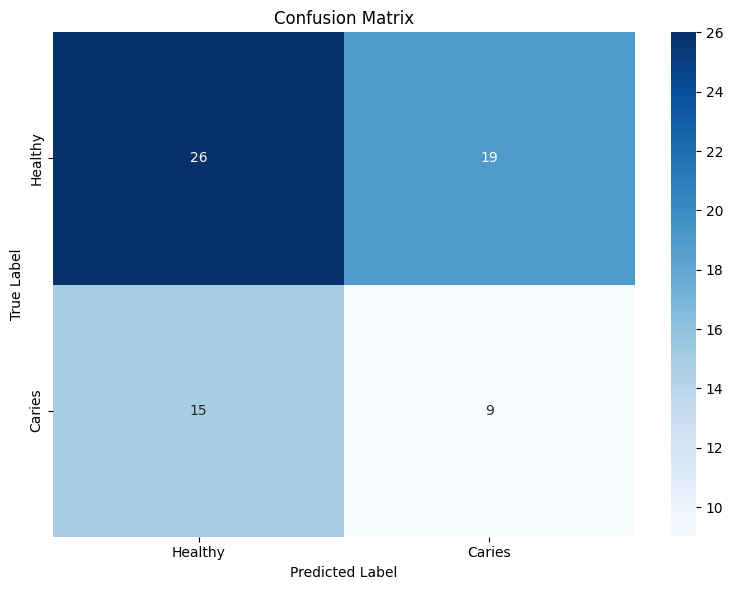

In [26]:
y_pred_proba = best_model.predict(val_dataset)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Healthy', 'Caries']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Caries'],
            yticklabels=['Healthy', 'Caries'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(str(output_dir / 'confusion_matrix.png'), dpi=150)
plt.show()

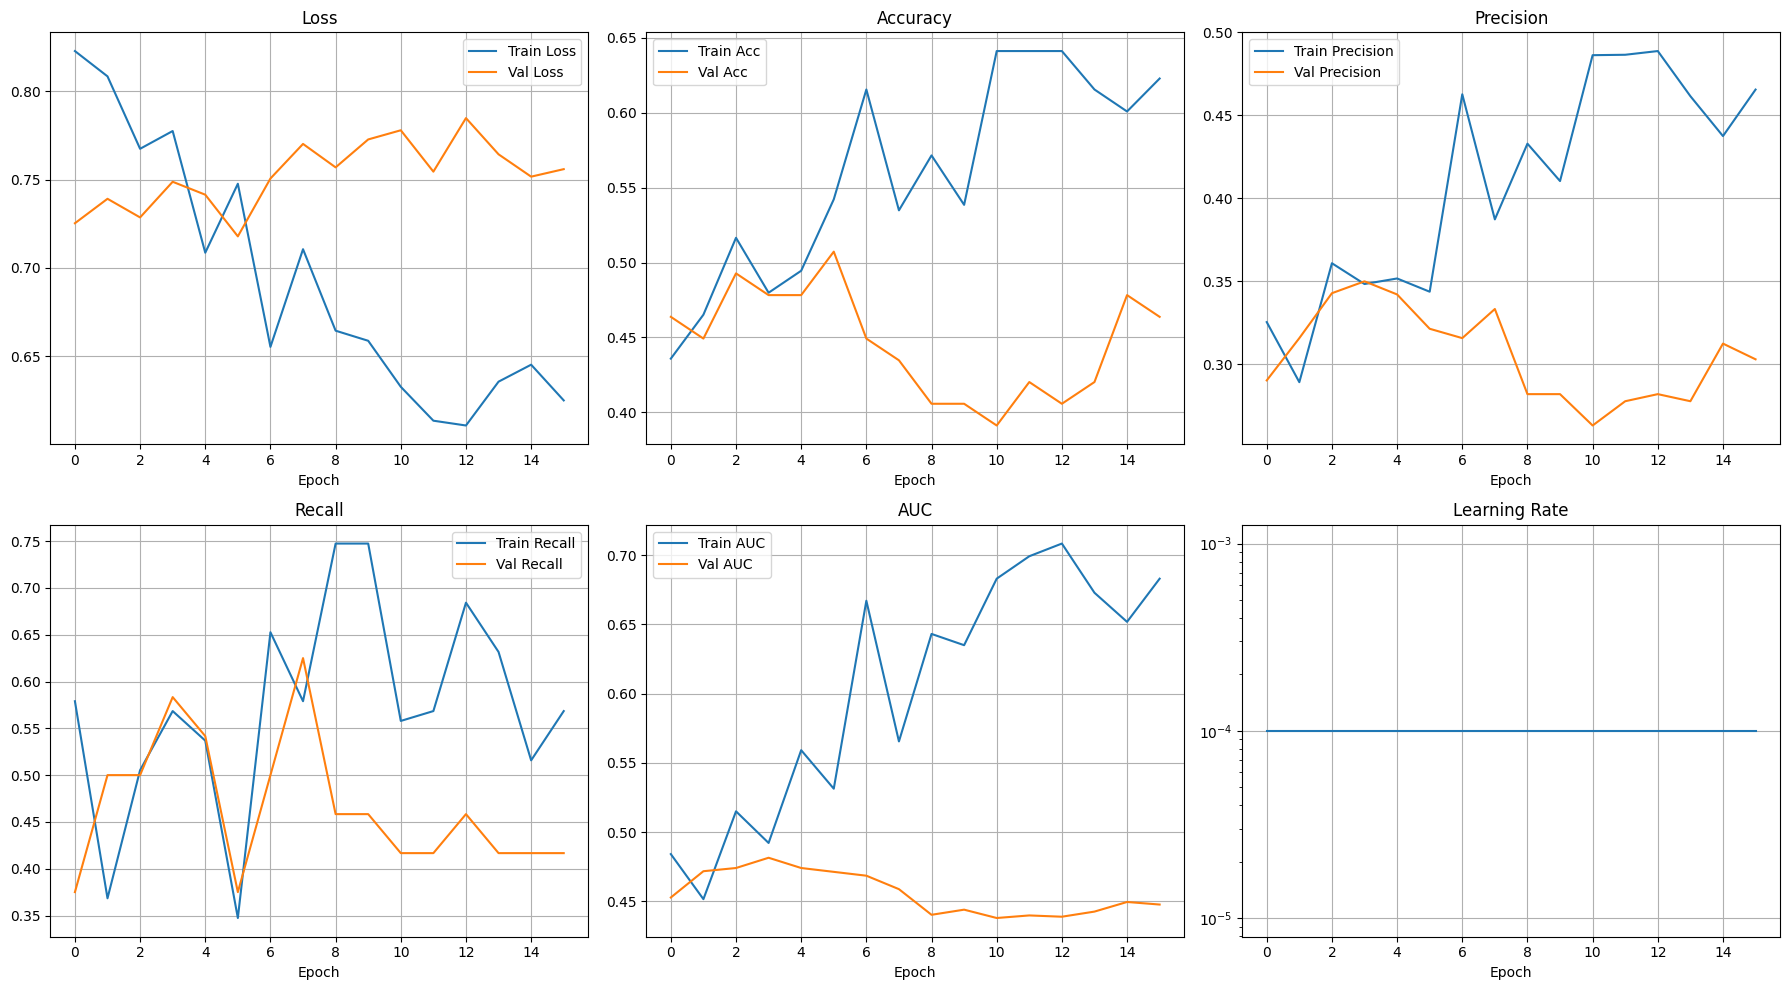

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Acc')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Acc')
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[0, 2].plot(history.history['precision'], label='Train Precision')
axes[0, 2].plot(history.history['val_precision'], label='Val Precision')
axes[0, 2].set_title('Precision')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Recall
axes[1, 0].plot(history.history['recall'], label='Train Recall')
axes[1, 0].plot(history.history['val_recall'], label='Val Recall')
axes[1, 0].set_title('Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

# AUC
axes[1, 1].plot(history.history['auc'], label='Train AUC')
axes[1, 1].plot(history.history['val_auc'], label='Val AUC')
axes[1, 1].set_title('AUC')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Learning Rate
axes[1, 2].plot(history.history.get('lr', [1e-4] * len(history.history['loss'])))
axes[1, 2].set_title('Learning Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig(str(output_dir / 'training_history.png'), dpi=150)
plt.show()



Visualizing predictions on validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


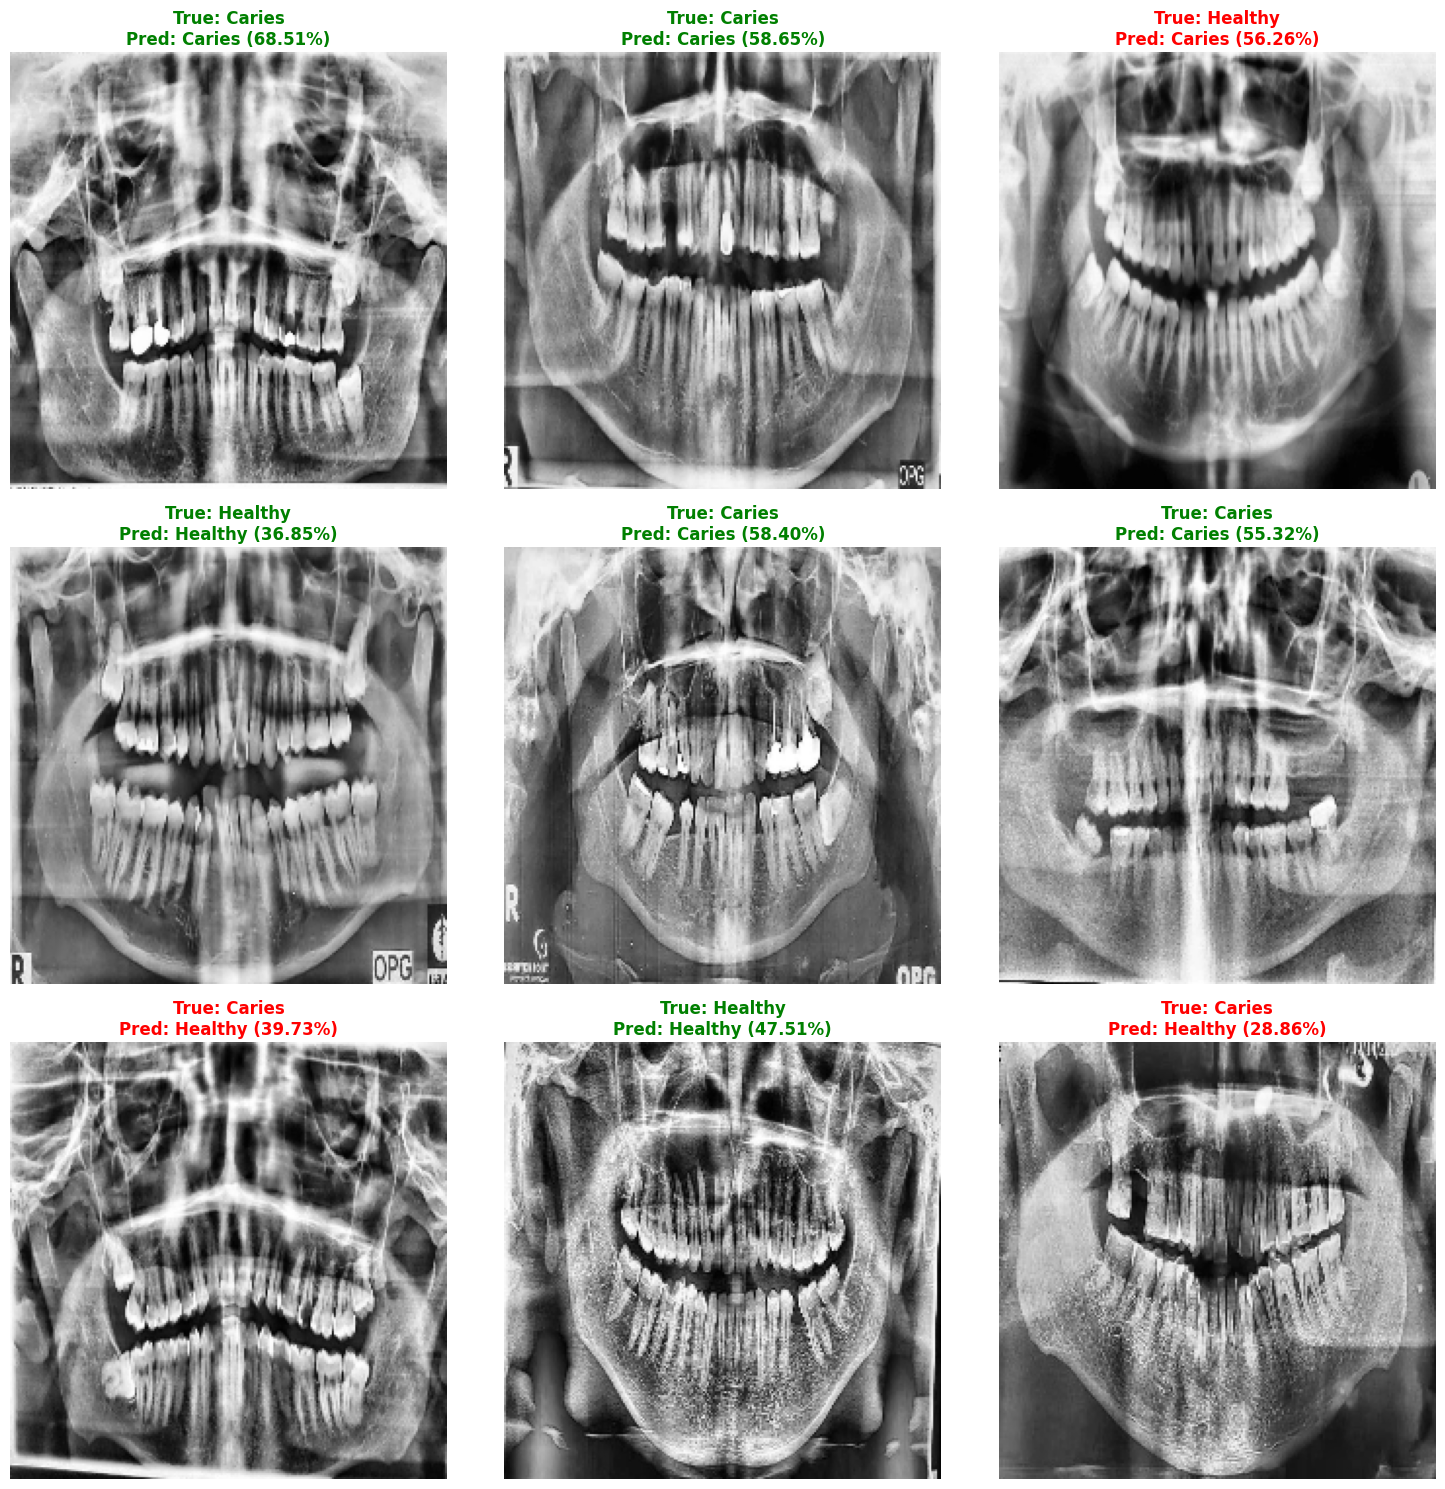

In [28]:
def visualize_predictions(model, dataset, num_samples=9):
    """Visualize model predictions"""
    # Get a batch of data
    for images, labels in dataset.take(1):
        predictions = model.predict(images)
        
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        axes = axes.flatten()
        
        for i in range(min(num_samples, len(images))):
            axes[i].imshow(images[i])
            
            true_label = 'Caries' if labels[i] == 1 else 'Healthy'
            pred_prob = predictions[i][0]
            pred_label = 'Caries' if pred_prob > 0.5 else 'Healthy'
            
            color = 'green' if true_label == pred_label else 'red'
            
            axes[i].set_title(
                f'True: {true_label}\nPred: {pred_label} ({pred_prob:.2%})',
                color=color,
                fontsize=12,
                fontweight='bold'
            )
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig(str(output_dir / 'predictions_visualization.png'), dpi=150)
        plt.show()
        break

print("\nVisualizing predictions on validation set...")
visualize_predictions(best_model, val_dataset)